In [8]:
import os
import torch
import numpy as np
import pandas as pd
from PIL import Image
from tqdm import tqdm

import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms, models
from torch.utils.data import DataLoader

from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)


In [9]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
device


device(type='cpu')

In [ ]:

DATA_ROOT = "/data/ecg_split"
train_dir = os.path.join(DATA_ROOT, "train")
val_dir = os.path.join(DATA_ROOT, "val")
test_dir = os.path.join(DATA_ROOT, "test")

# Verify paths exist
for d in [train_dir, val_dir, test_dir]:
    assert os.path.isdir(d), f"Directory not found: {d}"
print("All data directories found.")

# ── Transforms ──
train_transforms = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(5),
    transforms.ColorJitter(brightness=0.1, contrast=0.1),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

val_transforms = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])


All data directories found.


In [11]:
train_dataset = datasets.ImageFolder(train_dir, transform=train_transforms)
val_dataset = datasets.ImageFolder(val_dir, transform=val_transforms)
test_dataset = datasets.ImageFolder(test_dir, transform=val_transforms)

print("Class mapping:", train_dataset.class_to_idx)


Class mapping: {'abnormal': 0, 'normal': 1}


In [12]:
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)


In [13]:
class_counts = np.bincount(train_dataset.targets)
class_weights = torch.tensor(
    [len(train_dataset)/c for c in class_counts],
    dtype=torch.float
).to(device)

class_weights


tensor([3.7366, 1.3654])

In [14]:
model = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)

for param in model.parameters():
    param.requires_grad = False

model.fc = nn.Linear(model.fc.in_features, 2)

model = model.to(device)


In [15]:
criterion = nn.CrossEntropyLoss(weight=class_weights)
optimizer = optim.Adam(model.fc.parameters(), lr=1e-4)


In [16]:
def train_model(model, train_loader, val_loader, epochs=5):
    best_acc = 0
    history = {"train_acc": [], "val_acc": [], "train_loss": []}

    scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=3, gamma=0.5)

    for epoch in range(epochs):
        model.train()
        running_loss = 0
        correct = 0
        total = 0

        for images, labels in tqdm(train_loader, desc=f"Epoch {epoch+1}/{epochs}"):
            images = images.to(device)
            labels = labels.to(device)

            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            running_loss += loss.item()
            _, preds = torch.max(outputs, 1)
            correct += (preds == labels).sum().item()
            total += labels.size(0)

        train_acc = correct / total
        avg_loss = running_loss / len(train_loader)
        scheduler.step()

        # Validation
        model.eval()
        correct = 0
        total = 0

        with torch.no_grad():
            for images, labels in val_loader:
                images = images.to(device)
                labels = labels.to(device)
                outputs = model(images)
                _, preds = torch.max(outputs, 1)
                correct += (preds == labels).sum().item()
                total += labels.size(0)

        val_acc = correct / total

        history["train_acc"].append(train_acc)
        history["val_acc"].append(val_acc)
        history["train_loss"].append(avg_loss)

        print(f"Epoch {epoch+1}/{epochs} — Loss: {avg_loss:.4f} | Train Acc: {train_acc:.4f} | Val Acc: {val_acc:.4f}")

        if val_acc > best_acc:
            best_acc = val_acc
            torch.save(model.state_dict(), "best_ecg_model.pth")
            print(f"  ✓ Best model saved (val_acc: {val_acc:.4f})")

    print(f"\nBest Val Acc: {best_acc:.4f}")
    return history


In [17]:
history = train_model(model, train_loader, val_loader, epochs=5)


Epoch 1/5: 100%|██████████| 3921/3921 [49:53<00:00,  1.31it/s] 


Epoch 1/5 — Loss: 0.2332 | Train Acc: 0.8990 | Val Acc: 0.9516
  ✓ Best model saved (val_acc: 0.9516)


Epoch 2/5: 100%|██████████| 3921/3921 [55:44<00:00,  1.17it/s] 


Epoch 2/5 — Loss: 0.1448 | Train Acc: 0.9419 | Val Acc: 0.9560
  ✓ Best model saved (val_acc: 0.9560)


Epoch 3/5: 100%|██████████| 3921/3921 [47:25<00:00,  1.38it/s]


Epoch 3/5 — Loss: 0.1274 | Train Acc: 0.9486 | Val Acc: 0.9541


Epoch 4/5: 100%|██████████| 3921/3921 [46:13<00:00,  1.41it/s]


Epoch 4/5 — Loss: 0.1197 | Train Acc: 0.9519 | Val Acc: 0.9585
  ✓ Best model saved (val_acc: 0.9585)


Epoch 5/5: 100%|██████████| 3921/3921 [46:00<00:00,  1.42it/s]


Epoch 5/5 — Loss: 0.1178 | Train Acc: 0.9530 | Val Acc: 0.9649
  ✓ Best model saved (val_acc: 0.9649)

Best Val Acc: 0.9649


In [18]:
model.load_state_dict(torch.load("best_ecg_model.pth", map_location=device, weights_only=True))
model.eval()
print("Best model loaded.")


Best model loaded.


Classification Report:
              precision    recall  f1-score   support

    abnormal       0.92      0.96      0.94      7196
      normal       0.98      0.97      0.98     19692

    accuracy                           0.97     26888
   macro avg       0.95      0.96      0.96     26888
weighted avg       0.97      0.97      0.97     26888



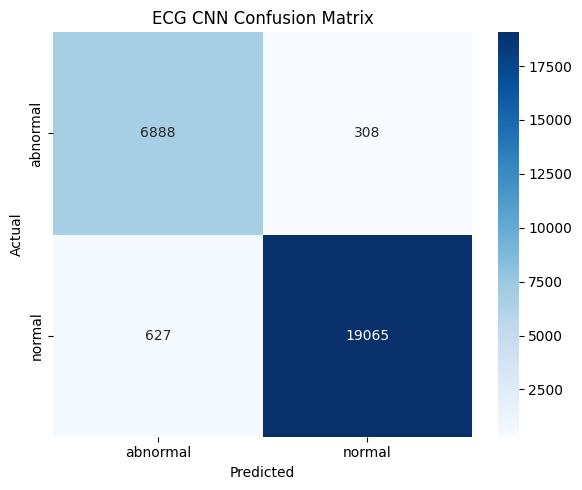

In [19]:
all_preds = []
all_labels = []

with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        outputs = model(images)
        _, preds = torch.max(outputs, 1)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.numpy())

class_names = list(test_dataset.class_to_idx.keys())
print("Classification Report:")
print(classification_report(all_labels, all_preds, target_names=class_names))

# Confusion Matrix
cm = confusion_matrix(all_labels, all_preds)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=class_names, yticklabels=class_names)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("ECG CNN Confusion Matrix")
plt.tight_layout()
plt.show()


In [20]:
import os
os.makedirs("saved_models", exist_ok=True)
torch.save(model.state_dict(), "saved_models/ecg_cnn_model.pth")
print("Model saved to saved_models/ecg_cnn_model.pth")


Model saved to saved_models/ecg_cnn_model.pth


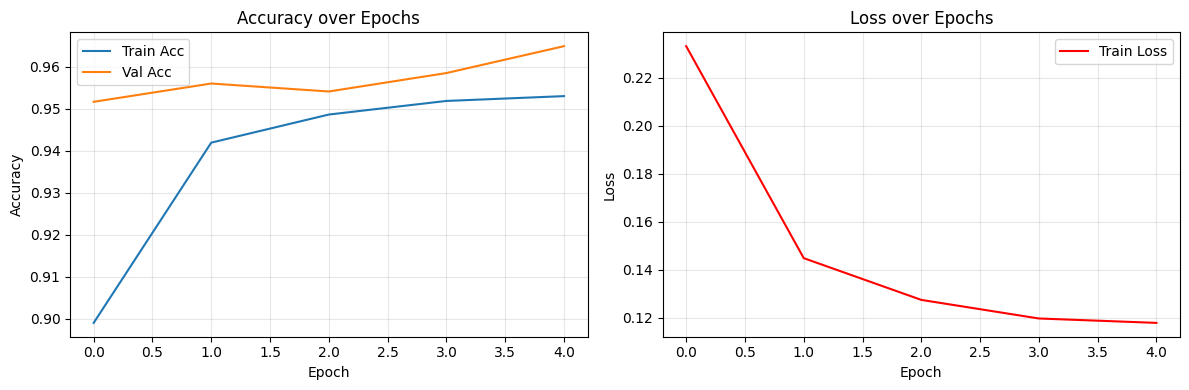

In [21]:
# Learning Curves
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(history["train_acc"], label="Train Acc")
axes[0].plot(history["val_acc"], label="Val Acc")
axes[0].set_title("Accuracy over Epochs")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Accuracy")
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot(history["train_loss"], label="Train Loss", color="red")
axes[1].set_title("Loss over Epochs")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Loss")
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()
